# Notebook 03 — Evaluación, Análisis de Costos y Submission de Kaggle
Evaluación profunda del modelo campeón, optimización del umbral y generación del archivo de submission.

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, f1_score, precision_recall_curve,
                              average_precision_score)
from src.models import calcular_costo_negocio, optimizar_umbral

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid')
print('Librerías cargadas.')


Librerías cargadas.


## 1. Cargar modelo campeón y datos

In [2]:
modelo_ganador = joblib.load('../data/processed/modelo_ganador.pkl')
meta           = joblib.load('../data/processed/ganador_meta.pkl')
y_val          = joblib.load('../data/processed/y_val.pkl')
test_ids       = joblib.load('../data/processed/test_ids.pkl')
X_test_kaggle  = joblib.load('../data/processed/X_test_kaggle.pkl')

X_val   = meta['X_val']
nombre  = meta['nombre']

print(f'Modelo cargado: {nombre}')
print(f'X_val: {X_val.shape}  |  Churn rate val: {y_val.mean():.3f}')

Modelo cargado: Rand.Forest  [balanced]
X_val: (1127, 29)  |  Churn rate val: 0.265


## 2. Predicciones con umbral 0.5 (baseline)

In [3]:
y_prob = modelo_ganador.predict_proba(X_val)[:, 1]
y_pred_05 = (y_prob >= 0.5).astype(int)

print('=== Reporte de Clasificación (umbral 0.50) ===')
print(classification_report(y_val, y_pred_05, target_names=['Retenido', 'Fugado'], digits=4))

neg_05 = calcular_costo_negocio(y_val, y_pred_05)
print('=== Análisis de Costo (umbral 0.50) ===')
for k, v in neg_05.items():
    print(f'  {k}: {v:,.2f}' if isinstance(v, float) else f'  {k}: {v}')


=== Reporte de Clasificación (umbral 0.50) ===
              precision    recall  f1-score   support

    Retenido     0.9028    0.7742    0.8336       828
      Fugado     0.5516    0.7692    0.6425       299

    accuracy                         0.7728      1127
   macro avg     0.7272    0.7717    0.7380      1127
weighted avg     0.8096    0.7728    0.7829      1127

=== Análisis de Costo (umbral 0.50) ===
  Verdaderos Positivos (Fugas Detectadas): 230
  Verdaderos Negativos (Leales Correctos): 641
  Falsos Positivos (Gastos Innecesarios): 187
  Falsos Negativos (Fugas No Detectadas): 69
  Costo Falsos Positivos ($): 3740
  Costo Falsos Negativos ($): 20700
  COSTO TOTAL ($): 24440
  Costo Modelo Naive ($): 89700
  Ahorro vs. Naive ($): 65260


## 3. Matriz de Confusión (umbral 0.5)

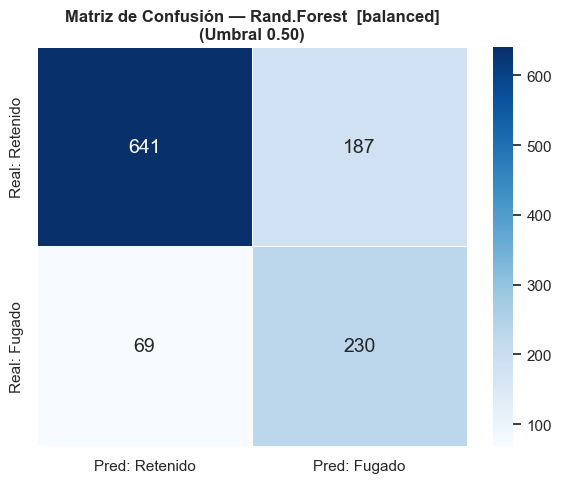

In [4]:
cm = confusion_matrix(y_val, y_pred_05)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=.5,
            xticklabels=['Pred: Retenido', 'Pred: Fugado'],
            yticklabels=['Real: Retenido', 'Real: Fugado'],
            annot_kws={'size': 14})
plt.title(f'Matriz de Confusión — {nombre}\n(Umbral 0.50)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_confusion_matrix_05.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Curva ROC y Curva Precision-Recall

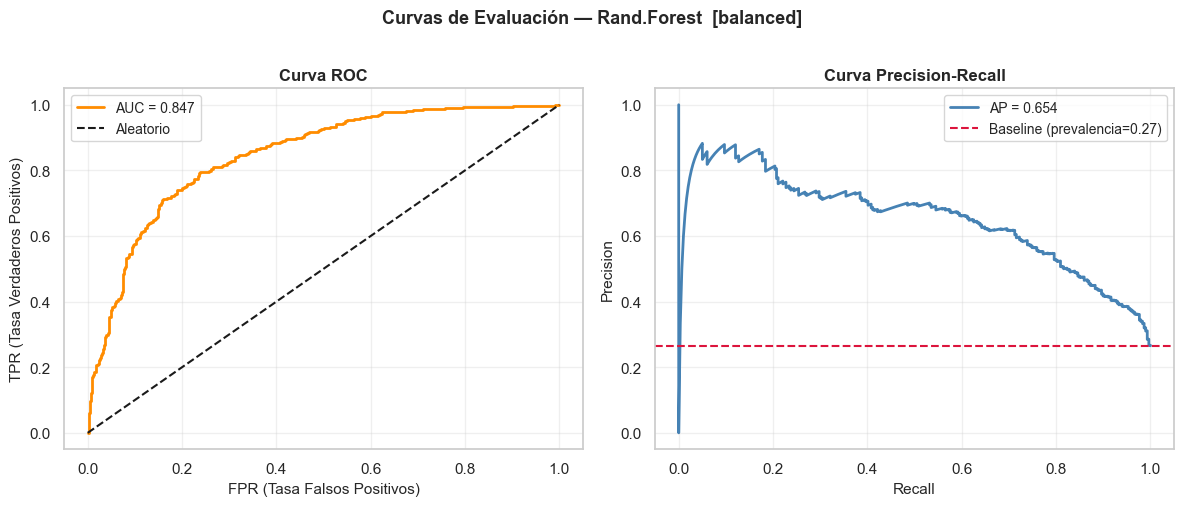

In [5]:
fpr, tpr, _ = roc_curve(y_val, y_prob)
roc_auc      = auc(fpr, tpr)

prec, rec, _ = precision_recall_curve(y_val, y_prob)
ap            = average_precision_score(y_val, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1.5, label='Aleatorio')
axes[0].set_xlabel('FPR (Tasa Falsos Positivos)', fontsize=11)
axes[0].set_ylabel('TPR (Tasa Verdaderos Positivos)', fontsize=11)
axes[0].set_title('Curva ROC', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)

# Precision-Recall
axes[1].plot(rec, prec, color='steelblue', lw=2, label=f'AP = {ap:.3f}')
axes[1].axhline(y_val.mean(), color='crimson', ls='--', lw=1.5,
                label=f'Baseline (prevalencia={y_val.mean():.2f})')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Curva Precision-Recall', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)

plt.suptitle(f'Curvas de Evaluación — {nombre}', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/fig_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Optimización del Umbral (criterio: minimizar costo financiero)

Umbral óptimo (costo mínimo): 0.40
Umbral óptimo (F1 máximo)   : 0.59


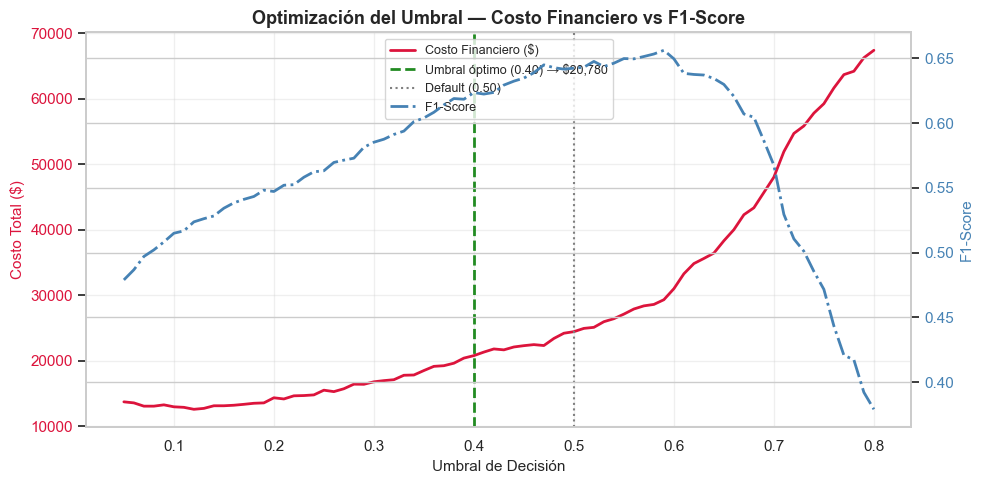

In [6]:
umbral_optimo, umbrales, costos, f1s = optimizar_umbral(y_val, y_prob, criterio='costo_f1_min')
idx_opt = np.argmin(costos)
umbral_f1, _, _, _  = optimizar_umbral(y_val, y_prob, criterio='f1')

costo_en_umbral_opt = costos[np.argmin(
    [c if f >= max(f1s)*0.95 else np.inf for c, f in zip(costos, f1s)]
)]

print(f'Umbral óptimo (costo mínimo): {umbral_optimo:.2f}')
print(f'Umbral óptimo (F1 máximo)   : {umbral_f1:.2f}')

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(umbrales, costos, color='crimson', lw=2, label='Costo Financiero ($)')
ax1.axvline(umbral_optimo, color='forestgreen', ls='--', lw=2,
            label=f'Umbral óptimo ({umbral_optimo:.2f}) → ${costo_en_umbral_opt:,.0f}')
ax1.axvline(0.5, color='gray', ls=':', lw=1.5, label='Default (0.50)')

ax2.plot(umbrales, f1s, color='steelblue', lw=2, ls='-.', label='F1-Score')
ax2.set_ylabel('F1-Score', fontsize=11, color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax1.set_xlabel('Umbral de Decisión', fontsize=11)
ax1.set_ylabel('Costo Total ($)', fontsize=11, color='crimson')
ax1.tick_params(axis='y', labelcolor='crimson')
ax1.set_title('Optimización del Umbral — Costo Financiero vs F1-Score', fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', fontsize=9)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/fig_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Evaluación con umbral óptimo

In [7]:
y_pred_opt = (y_prob >= umbral_optimo).astype(int)

print(f'=== Reporte con umbral óptimo ({umbral_optimo:.2f}) ===')
print(classification_report(y_val, y_pred_opt, target_names=['Retenido', 'Fugado'], digits=4))

neg_opt = calcular_costo_negocio(y_val, y_pred_opt)

# Comparativa financiera
print('\n=== COMPARATIVA FINANCIERA ===')
print(f'  Umbral 0.50  → Costo: ${calcular_costo_negocio(y_val, y_pred_05)["COSTO TOTAL ($)"]:>10,.2f}')
print(f'  Umbral {umbral_optimo:.2f} → Costo: ${neg_opt["COSTO TOTAL ($)"]:>10,.2f}')
print(f'  Ahorro:         ${calcular_costo_negocio(y_val, y_pred_05)["COSTO TOTAL ($)"] - neg_opt["COSTO TOTAL ($)"]:>10,.2f}')
print(f'  Ahorro vs. naive: ${neg_opt["Ahorro vs. Naive ($)"]:>9,.2f}')


=== Reporte con umbral óptimo (0.40) ===
              precision    recall  f1-score   support

    Retenido     0.9168    0.7053    0.7973       828
      Fugado     0.5020    0.8227    0.6236       299

    accuracy                         0.7365      1127
   macro avg     0.7094    0.7640    0.7104      1127
weighted avg     0.8068    0.7365    0.7512      1127


=== COMPARATIVA FINANCIERA ===
  Umbral 0.50  → Costo: $ 24,440.00
  Umbral 0.40 → Costo: $ 20,780.00
  Ahorro:         $  3,660.00
  Ahorro vs. naive: $68,920.00


## 7. Matriz de Confusión con umbral óptimo

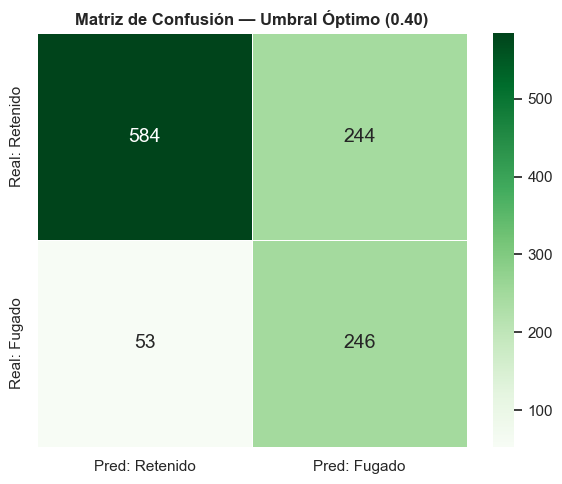

In [8]:
cm_opt = confusion_matrix(y_val, y_pred_opt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', linewidths=.5,
            xticklabels=['Pred: Retenido', 'Pred: Fugado'],
            yticklabels=['Real: Retenido', 'Real: Fugado'],
            annot_kws={'size': 14})
plt.title(f'Matriz de Confusión — Umbral Óptimo ({umbral_optimo:.2f})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_confusion_matrix_opt.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Generar submission para Kaggle

In [9]:
# X_val fue guardado con las columnas exactas que usó el modelo (post-depuración).
# Usamos esas mismas columnas para alinear X_test y garantizar consistencia.
X_test_sub = X_test_kaggle[X_val.columns]

y_prob_test = modelo_ganador.predict_proba(X_test_sub)[:, 1]
y_pred_test = (y_prob_test >= umbral_optimo).astype(int)

submission = pd.DataFrame({'customerID': test_ids, 'Churn': y_pred_test})
submission.to_csv('../data/processed/submission_kaggle.csv', index=False)

print(' Submission generado: data/processed/submission_kaggle.csv')
print(f'   Total predicciones : {len(submission)}')
print(f'   Churn predicho     : {y_pred_test.sum()} ({y_pred_test.mean()*100:.1f}%)')
display(submission.head(10))

 Submission generado: data/processed/submission_kaggle.csv
   Total predicciones : 1409
   Churn predicho     : 626 (44.4%)


,customerID,Churn
0,4376-KFVRS,0
1,2754-SDJRD,1
2,9917-KWRBE,0
3,0365-GXEZS,1
4,9385-NXKDA,0
5,4686-UXDML,1
6,2227-JRSJX,1
7,4830-FAXFM,0
8,1830-IPXVJ,0
9,4690-LLKUA,1
